## Clasificación de parcelas con Sentinel-2 y embeddings Alphaearth

#### Objetivo

Se construyó un flujo para clasificar parcelas agrícolas a partir de imágenes satelitales. El proceso combina etiquetas vectoriales/raster (las “máscaras” de clases), imágenes Sentinel-2 y embeddings (representaciones numéricas ricas) para entrenar modelos como k-NN y Random Forest, validar su desempeño y visualizar resultados por parcela.

#### Inputs

- Máscaras de clase (una por parcela) con valores válidos 1–249 y valor 255 como sin dato.

- Proyección de referencia: EPSG:2154 (Lambert-93); tamaño de píxel ~ 10 m.

- Sentinel-2 SR armonizado del año de interés, con banda QA60 para nubes/cirros.

- Embeddings AlphaEarth (64 bandas por píxel) del mismo año y zona.

- ROI: área de trabajo resultante de unir los contornos de todas las máscaras.

## Cargar y revisar una máscara `TARGET` de PASTIS

Localiza el primer archivo `TARGET_*.npy` dentro de `ANNOTATIONS/`, lo carga y **normaliza su forma** para obtener una máscara 2D (`class_map`) donde cada píxel es un **ID de clase**. Muestra las **clases únicas** detectadas y una **vista rápida** con `imshow`.

Este es el *sanity check* inicial: confirmar **dimensiones**, **tipo de dato** y **rango de clases** evita fallas posteriores al calcular distribuciones, cruzar con **embeddings** o superponer con polígonos en Earth Engine. Detectar un `shape` inesperado desde el inicio ahorra tiempo de depuración.

### Conceptos clave
- **Máscara semántica**: raster 2D donde el valor del píxel indica la clase (p. ej., cultivo).
- **Rango de clases en PASTIS**: típicamente `0..19` (18 cultivos + `background` + `void`).
- **Variantes de forma**: `TARGET` puede venir como `(C, H, W)` con `C∈{1,3}`, como `H×W`, o como `(H, W, C)`. Se reordena para quedarse con la **banda 0** como máscara de clases.
- **Visualización rápida**: `imshow` colorea los IDs con un gradiente continuo; útil para ver patrones, aunque no es una paleta categórica.


Leyendo: ../PASTIS/PASTIS\ANNOTATIONS\TARGET_10005.npy
shape: (3, 128, 128) dtype: uint8
Clases únicas en banda 0: [ 0  1  2  3  4  6  7 10 12 13 14 17 19] … (total: 13 )
Rango esperado 0..19 (18 cultivos + background + void)
Valores únicos banda 1: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] …
Valores únicos banda 2: [ 0  1  2  3  6 10 11 12 19 20 21 27 31 50 51 55 57 63 73 76] …


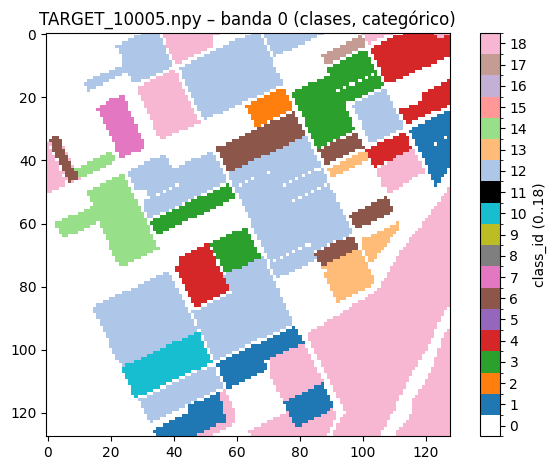

In [32]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

ROOT = r"../PASTIS/PASTIS"   

target_paths = sorted(glob.glob(os.path.join(ROOT, "ANNOTATIONS", "TARGET_*.npy")))
assert len(target_paths) > 0, "No encontré archivos TARGET_*.npy"
fp = target_paths[5]
print("Leyendo:", fp)

arr = np.load(fp)  # típicamente shape (3, 128, 128)
print("shape:", arr.shape, "dtype:", arr.dtype)

if arr.ndim == 3 and arr.shape[0] in (1, 3):
    class_map = arr[0]               # <- la banda 0 es la máscara semántica
elif arr.ndim == 2:
    class_map = arr                  # ya es 2D
elif arr.ndim == 3 and arr.shape[-1] in (1, 3):
    class_map = np.moveaxis(arr, -1, 0)[0]
else:
    raise ValueError("Formato inesperado para TARGET")

u = np.unique(class_map)
print("Clases únicas en banda 0:", u[:50], "… (total:", u.size, ")")
print("Rango esperado 0..19 (18 cultivos + background + void)")

if arr.ndim == 3 and arr.shape[0] >= 3:
    print("Valores únicos banda 1:", np.unique(arr[1])[:20], "…")
    print("Valores únicos banda 2:", np.unique(arr[2])[:20], "…")

# Paleta categórica de 19 colores (clases 0..18)
palette19 = ['#ffffff', '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
             '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
             '#000000','#aec7e8','#ffbb78','#98df8a','#ff9896',
             '#c5b0d5','#c49c94','#f7b6d2','#c7c7c7']

# --- Si tus clases SON 0..18 (19 clases) ---
n_classes = 19                        # clases 0..18
cmap = ListedColormap(palette19[:n_classes], name='pastis19')
bounds = np.arange(-0.5, n_classes + 0.5, 1)  # [-0.5, 0.5, 1.5, ..., 18.5]
norm = BoundaryNorm(bounds, cmap.N)

plt.figure()
plt.title(os.path.basename(fp) + " – banda 0 (clases, categórico)")
im = plt.imshow(class_map, cmap=cmap, norm=norm, interpolation="nearest")
cbar = plt.colorbar(im, ticks=np.arange(n_classes))
cbar.ax.set_ylabel("class_id (0..18)")
plt.tight_layout()
plt.show()

## Enumerar máscaras en Earth Engine por prefijo/sufijo


Recorre los *assets* del proyecto en Google Earth Engine (`projects/fonseca-472504/assets`), filtra aquellos de tipo **IMAGE** cuyo nombre siga el patrón **`mask_…_epsg2154_rot`** y construye una lista ordenada de IDs completos. Al final imprime el **conteo** de máscaras encontradas y sus rutas.

Antes de cruzar máscaras con polígonos, embeddings o tiempos, necesitamos un **inventario confiable** de qué hay en el repositorio del proyecto y bajo qué **convención de nombres**. Este paso garantiza:
- que **existen** las máscaras esperadas,
- que comparten una **proyección/CRS** conocida (EPSG:2154) y un estado (p. ej., *rotated*),
- y que podremos **automatizar** los siguientes pasos (cargar, mosaicar, muestrear) sin ambigüedades de nombres.

### Conceptos clave
- **Asset (Earth Engine)**: Recurso almacenado (p. ej., *IMAGE*, *IMAGE_COLLECTION*, *TABLE*). Aquí filtramos solo `type == "IMAGE"`.
- **ID completo vs. nombre base**: `a['name']` devuelve la ruta completa (`projects/.../assets/mask_...`). `base = name.split('/')[-1]` extrae el nombre “corto” para evaluar prefijo/sufijo.
- **Convención de nombres**: `MASK_PREFIX='mask_'` y `MASK_SUFFIX='_epsg2154_rot'` permiten filtrar por **intención** (máscara), **CRS** (EPSG:2154/Lambert-93) y **transformación** (rotada).
- **Orden y trazabilidad**: Ordenar (`sorted`) los IDs facilita reproducibilidad y auditoría en procesos por lotes.


In [2]:
import ee
ee.Initialize(project='fonseca-472504')

PROJECT_ROOT = 'projects/fonseca-472504/assets'
MASK_PREFIX  = 'mask_'
MASK_SUFFIX  = '_epsg2154_rot'

assets = ee.data.listAssets({'parent': PROJECT_ROOT}).get('assets', [])
mask_ids = []
for a in assets:
    if a.get('type') == 'IMAGE':
        name = a['name']
        base = name.split('/')[-1]
        if base.startswith(MASK_PREFIX) and base.endswith(MASK_SUFFIX):
            mask_ids.append(name)
mask_ids = sorted(mask_ids)

print("Máscaras encontradas:", len(mask_ids))
for i in mask_ids: 
    print(" •", i)


Máscaras encontradas: 114
 • projects/fonseca-472504/assets/mask_10000_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10001_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10002_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10003_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10004_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10005_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10006_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10007_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10008_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10009_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10010_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10011_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10012_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10013_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10014_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10015_epsg2154_rot
 • projects/fonseca-472504/assets/mask_10016_e

## Inspección de una máscara en EE: proyección, escala y estadísticos básicos

Elige una máscara (`mask_id`), carga la **banda 0** como `label` y:
1) Reporta su **CRS** y **escala nominal**.
2) Aplica un filtro de **valores válidos** `[1..249]` (tratando `255` como **NODATA**) vía `updateMask`.
3) Calcula:
   - el **conteo de píxeles válidos** (`Reducer.count`), y
   - el **histograma de frecuencias** por valor de etiqueta (`Reducer.frequencyHistogram`),
   dentro del **footprint del asset** a `scale=10` m.

- **Alineación espacial**: conocer `CRS` y `nominalScale` evita desajustes cuando combines con Sentinel-2 (10 m), embeddings o polígonos.
- **Calidad de etiquetas**: enmascarar NODATA antes de contar/histogramar previene sesgos y falsos positivos en métricas.
- **Diagnóstico rápido**: el histograma revela **clases fuera de rango**, etiquetas raras o dominios inconsistentes entre máscaras.

### Conceptos clave
- **`projection()` y `nominalScale()`**: definen el CRS y la resolución base de la **primera banda** (aquí, la 0). Guían el `scale` de los reductores.
- **Máscara vs. valores** (`updateMask`) : conserva sólo píxeles cuyo valor cae en `[VALID_MIN, VALID_MAX]`. Los demás quedan **enmascarados** (no cuentan).
- **`geometry=img.geometry()`**: limita el cómputo al footprint del asset; evita contar áreas fuera del raster.
- **Reductores**:
  - `Reducer.count()` → número de píxeles **no enmascarados**.
  - `Reducer.frequencyHistogram()` → diccionario `{valor: conteo}` de etiquetas.
- **Parámetros de evaluación**:
  - `scale=10` (m) para coherencia con S2.
  - `maxPixels` alto para escenas grandes.
  - `getInfo()` trae resultados al cliente (ejecuta el gráfico de cómputo).
- **Rangos de etiqueta**: el `[1..249]` es una **convención operativa** para estos assets; ajusta si tu dominio real incluye `0` (p. ej., *background*) o si NODATA tiene otro código.


In [3]:
mask_id = mask_ids[0]
img = ee.Image(mask_id).select(0)

# proyección y escala
proj = img.projection()
print("CRS:", proj.getInfo()['crs'])
print("nominalScale (m):", ee.Number(proj.nominalScale()).getInfo())

# cuenta de píxeles válidos (1..249). 255 lo tratamos como NODATA.
VALID_MIN, VALID_MAX = 1, 249
label = img.updateMask(img.gte(VALID_MIN).And(img.lte(VALID_MAX))).rename('label')

cnt = label.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=img.geometry(),     # solo dentro del footprint del asset
    scale=10,                    # ~10 m
    maxPixels=1e13
).get('label').getInfo()

hist = label.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=img.geometry(),
    scale=10,
    maxPixels=1e13
).get('label').getInfo()

print("Pix válidos (1..249):", cnt)
print("Histograma (valor:pix):", hist)


CRS: EPSG:2154
nominalScale (m): 10.00760046886615
Pix válidos (1..249): 13081
Histograma (valor:pix): {'1': 2551, '12': 7119, '13': 556, '19': 569, '2': 822, '3': 1279, '4': 126, '6': 59}


## Auditoría masiva de máscaras: conteo de píxeles válidos y filtrado

Itera por todos los IDs de máscaras (`mask_ids`), aplica la misma regla de validez de etiquetas (`VALID_MIN..VALID_MAX`) sobre la **banda 0**, y para cada asset:
- calcula el **conteo de píxeles válidos** con `Reducer.count()` dentro del **footprint** del propio raster a `scale=10` m,
- guarda en `audit` una tupla `(nombre_base, conteo)`,
- y, si `conteo > 0`, agrega el ID a `valid_ids`.

Al final imprime un resumen `(asset, px válidos)` y el total de **máscaras válidas** detectadas.

- **Higiene de datos**: descarta assets vacíos, corruptos o totalmente NODATA antes de cualquier modelado o muestreo.
- **Reproducibilidad**: construir una “**lista blanca**” (`valid_ids`) evita resultados inestables por incluir máscaras sin información útil.
- **Diagnóstico temprano**: el resumen revela outliers (p. ej., máscaras con muy pocos píxeles) y permite trazar acciones (reprocesar, excluir, revisar CRS).

### Conceptos clave
- **Server- vs client-side** en EE: cada `getInfo()` dentro del bucle **dispara un cálculo remoto** por asset; es simple pero puede ser más lento en lotes grandes.
- **Footprint del asset** (`geometry=img.geometry()`): asegura que el conteo se mida sólo donde existe el raster, evitando áreas externas.
- **Resolución de cómputo** (`scale=10`): alineada con Sentinel-2; coherencia de escala = conteos comparables entre máscaras.
- **Nombrado base** (`mid.split('/')[-1]`): útil para reportes legibles sin perder el ID completo en `valid_ids`.
- **Umbral de validez** (`VALID_MIN..VALID_MAX`): convención operativa que define qué valores representan **etiquetas** y cuáles son **NODATA**; ajusta según tu dominio real.


In [4]:
audit = []
valid_ids = []

for mid in mask_ids[:99]:
    img = ee.Image(mid).select(0)
    lab = img.updateMask(img.gte(VALID_MIN).And(img.lte(VALID_MAX))).rename('label')
    cnt = (lab.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=img.geometry(),   # dentro del footprint del propio asset
        scale=10,
        maxPixels=1e13
    ).get('label').getInfo() or 0)
    audit.append((mid.split('/')[-1], cnt))
    if cnt > 0:
        valid_ids.append(mid)

print("Resumen auditoría (asset, px válidos):")
for name, cnt in audit:
    print(f"{name:28s}  {cnt}")
print("\nMáscaras válidas:", len(valid_ids))


Resumen auditoría (asset, px válidos):
mask_10000_epsg2154_rot       13081
mask_10001_epsg2154_rot       8000
mask_10002_epsg2154_rot       10146
mask_10003_epsg2154_rot       13354
mask_10004_epsg2154_rot       3347
mask_10005_epsg2154_rot       10480
mask_10006_epsg2154_rot       12227
mask_10007_epsg2154_rot       4188
mask_10008_epsg2154_rot       2281
mask_10009_epsg2154_rot       15698
mask_10010_epsg2154_rot       13440
mask_10011_epsg2154_rot       10899
mask_10012_epsg2154_rot       15331
mask_10013_epsg2154_rot       13254
mask_10014_epsg2154_rot       10079
mask_10015_epsg2154_rot       2026
mask_10016_epsg2154_rot       13125
mask_10017_epsg2154_rot       11488
mask_10018_epsg2154_rot       14320
mask_10019_epsg2154_rot       8469
mask_10020_epsg2154_rot       8469
mask_10021_epsg2154_rot       9564
mask_10022_epsg2154_rot       13763
mask_10023_epsg2154_rot       13200
mask_10024_epsg2154_rot       13144
mask_10025_epsg2154_rot       12544
mask_10026_epsg2154_rot       103

## Construir una ROI unificada a partir de los *footprints* de las máscaras

Toma cada `valid_id`, extrae su **geometría de footprint** (`ee.Image(mid).geometry()`), crea una `FeatureCollection` con todas ellas y ejecuta `union(ee.ErrorMargin(1))` para **disolver/combinar** los polígonos en una sola **ROI** continua (`ROI`). Esto elimina juntas y micro-grietas entre tiles y deja una geometría única lista para usar en reducciones o visualizaciones.

Trabajar con una **ROI unificada**:
- garantiza que los cálculos (conteos, histogramas, muestreos) se limiten exactamente a **donde hay datos**,
- evita **doble conteo** en zonas solapadas y reduce errores por huecos mínimos entre máscaras,
- simplifica el pipeline (una sola geometría en vez de cientos) y suele **abaratar/comprimir** el coste de cómputo en Earth Engine.

### Conceptos clave
- **Footprint**: la cobertura espacial real de cada asset raster (`Image.geometry()`); difiere del *bounding box*.
- **`FeatureCollection([...])` + `union()`**: fusiona múltiples polígonos en uno, resolviendo solapes y fronteras compartidas.
- **`ee.ErrorMargin(1)`**: tolerancia (≈1 m) para “pegar” bordes y eliminar *slivers*; ajusta si tus datos están a otra escala.
- **Server vs. client**: la unión ocurre **server-side**; si hay miles de máscaras, considera atajos como `ee.ImageCollection(valid_ids).geometry()` o `fc.geometry().dissolve(1)` para mejorar rendimiento.


In [5]:
roi_fc = ee.FeatureCollection([ee.Feature(ee.Image(mid).geometry()) for mid in valid_ids])
ROI = roi_fc.union(ee.ErrorMargin(1)).geometry()
print("ROI ok (geom unida).")


ROI ok (geom unida).


## Mosaicar etiquetas válidas y calcular métricas globales

- Construye una `ImageCollection` con todas las máscaras **válidas** (`valid_ids`), selecciona la **banda 0** y aplica la máscara de validez `[VALID_MIN..VALID_MAX]`.  
- Genera un **mosaico** (`mosaic()`) y lo **recorta** a la ROI unificada (`clip(ROI)`), quedándose con una sola `Image` de etiquetas (`label`).  
- Obtiene la **proyección** nativa (Lambert-93, EPSG:2154) y su **escala nominal**.  
- Calcula **conteo de píxeles** y **histograma de clases** del mosaico en la propia proyección, controlando memoria con `tileScale`.

- **Consolidación**: pasar de múltiples tiles a un *único raster* de etiquetas simplifica muestreos, cruces y visualizaciones.  
- **Consistencia espacial**: al usar el **CRS y escala del mosaico** en los reductores, las métricas son comparables con Sentinel-2 (10 m) y con el resto del pipeline.  
- **Diagnóstico global**: conteos e histogramas a nivel región detectan **clases fuera de dominio**, **huecos** (NODATA) y **desbalance** antes del modelado.

### Conceptos clave
- **`ImageCollection.mosaic()`**: compone píxel a píxel tomando el **primer píxel no enmascarado en el orden de la colección**; el **orden importa**. Si necesitas prioridades específicas, **ordena** la colección antes (`.sort('system:index')`, por ejemplo).  
- **Máscara de validez** (`updateMask`): excluir NODATA antes de mosaicar evita “contagiar” vacíos al mosaico final.  
- **`clip(ROI)`**: limita el raster al área efectiva de trabajo y reduce coste de cómputo.  
- **Proyección y escala**: `label.projection()` devuelve el **CRS/transform** efectivo del mosaico. Usarlo en `reduceRegion` (`crs` + `scale`) asegura que los conteos se hagan en la **rejilla nativa**.  
- **`tileScale`**: factor para dividir el trabajo en *tiles* más pequeños y evitar errores de memoria en reducciones.  
- **Tipos enteros** (`toInt()`): garantizan claves **enteras** en el histograma de clases (los diccionarios JSON devueltos tendrán claves numéricas coherentes).  
- **Heterogeneidad de entradas**: si las máscaras de origen tienen CRS/escala diferentes, el mosaico reproyecta implícitamente; para total control, usa `reproject('EPSG:2154', null, 10)` antes de reducir.


In [6]:
# Mosaico (1..249) recortado al ROI
label_ic = ee.ImageCollection([
    ee.Image(mid).select(0).updateMask(
        ee.Image(mid).select(0).gte(VALID_MIN).And(ee.Image(mid).select(0).lte(VALID_MAX))
    ).rename('label').toInt()
    for mid in valid_ids
])
label = label_ic.mosaic().clip(ROI).rename('label').toInt()

# Proyección/escala del mosaico (EPSG:2154)
lambert = label.projection()
SCALE = ee.Number(lambert.nominalScale()).getInfo()
print("Label CRS:", lambert.getInfo()['crs'], "| scale(m):", SCALE)

# Conteos globales del mosaico
px_lab = label.reduceRegion(
    reducer=ee.Reducer.count(), geometry=ROI,
    crs=lambert, scale=SCALE, maxPixels=1e13, tileScale=4
).get('label').getInfo()
hist_lab = label.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(), geometry=ROI,
    crs=lambert, scale=SCALE, maxPixels=1e13, tileScale=4
).get('label').getInfo()

print("Pix etiquetados (mosaico L93):", px_lab or 0)
print("Hist etiquetas mosaico:", hist_lab or {})


Label CRS: EPSG:4326 | scale(m): 111319.49079327357
Pix etiquetados (mosaico L93): 0
Hist etiquetas mosaico: {}


In [7]:
print("valid_ids:", len(valid_ids))
print("primeros 5:", valid_ids[:5])


valid_ids: 99
primeros 5: ['projects/fonseca-472504/assets/mask_10000_epsg2154_rot', 'projects/fonseca-472504/assets/mask_10001_epsg2154_rot', 'projects/fonseca-472504/assets/mask_10002_epsg2154_rot', 'projects/fonseca-472504/assets/mask_10003_epsg2154_rot', 'projects/fonseca-472504/assets/mask_10004_epsg2154_rot']


In [8]:
img0  = ee.Image(valid_ids[0]).select(0)
lab0  = img0.updateMask(img0.gte(1).And(img0.lte(249))).rename('label').toInt()

print("lab0 proj:", lab0.projection().getInfo())
cnt0 = lab0.reduceRegion(
    ee.Reducer.count(), geometry=img0.geometry(),
    scale=10, maxPixels=1e13
).get('label').getInfo()
print("lab0 count:", cnt0)


lab0 proj: {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}
lab0 count: 13081


## Construir una ImageCollection explícita y verificar metadatos

Crea una `ImageCollection` **explícita** con `ee.ImageCollection.fromImages([...])` a partir de todas las máscaras válidas (`valid_ids`). Para cada asset:
- selecciona la **banda 0**, aplica la máscara de validez `[1..249]`,
- renombra la banda a `label` y castea a entero (`toInt()`).

Luego imprime:
- el **tamaño** de la colección (`size()`), y
- la **proyección** de la primera imagen (CRS/transform/escala) para inspección rápida.

- **Control explícito**: `fromImages` deja claro que la colección se construye con una **lista concreta de imágenes**, útil para trazabilidad y para respetar un **orden** conocido cuando más adelante se use `mosaic()` (el orden de la colección afecta qué píxel gana).
- **Sanidad de metadatos**: verificar la **proyección** de la primera imagen evita inconsistencias de CRS/escala entre entradas antes de mosaicar o reducir.
- **Integridad de etiquetas**: renombrar a `label` y castear a `Int` asegura que las reducciones (e.g., histogramas) produzcan claves enteras y consistentes.

### Conceptos clave
- **`ee.ImageCollection.fromImages([...])`**: construye una colección del lado servidor a partir de una lista explícita de `ee.Image`. Similar a `ee.ImageCollection([...])`, pero más claro en intención.
- **Máscara de validez** (`updateMask`): excluye NODATA (`<1` o `>249`) antes de cualquier operación; evita contaminar mosaicos.
- **`size().getInfo()` y `projection().getInfo()`**: llamadas **client-side** que disparan cómputo remoto; úsalas para auditoría, no en bucles muy grandes.
- **Orden de la colección**: si se planea `mosaic()`, considera ordenar (`.sort('system:index')` o una propiedad propia) para priorizar imágenes.


In [9]:
label_ic = ee.ImageCollection.fromImages([
    ee.Image(mid).select(0)
      .updateMask(ee.Image(mid).select(0).gte(1).And(ee.Image(mid).select(0).lte(249)))
      .rename('label').toInt()
    for mid in valid_ids
])

print("label_ic.size():", label_ic.size().getInfo())
print("primera imagen proj:", ee.Image(label_ic.first()).projection().getInfo())


label_ic.size(): 99
primera imagen proj: {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}


In [10]:
mosaic_no_clip = label_ic.mosaic()              # sin clip todavía
print("mosaic_no_clip proj:", mosaic_no_clip.projection().getInfo())

mosaic_masked = mosaic_no_clip.updateMask(mosaic_no_clip.neq(0)).rename('label').toInt()

cnt_mosaic = mosaic_masked.reduceRegion(
    ee.Reducer.count(), geometry=img0.geometry(),   # usa geom de una máscara
    scale=10, maxPixels=1e13
).get('label').getInfo()
print("mosaic_no_clip count (geom img0):", cnt_mosaic)


mosaic_no_clip proj: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}
mosaic_no_clip count (geom img0): 20195


## Recortar el mosaico a la ROI, fijar proyección de referencia y contar píxeles etiquetados

- **Recorta** el mosaico de etiquetas (`mosaic_no_clip`) a la **ROI** unificada → `mosaic_clip = mosaic_no_clip.clip(ROI)`.
- **Enmascara el valor 0** (asumido como *background/NODATA*) para que no cuente en métricas → `updateMask(mosaic_clip.neq(0))`, renombra a `label` y castea a entero.
- **Fija una proyección de referencia** (`lambert`) tomando la proyección de la **primera imagen válida** (`valid_ids[0]`) y obtiene su **escala nominal** (`SCALE`).
- Ejecuta una **reducción** (`Reducer.count`) sobre la ROI usando esa **proyección y escala explícitas** para obtener el número de **píxeles etiquetados** (no enmascarados).

- **Recorte exacto**: `clip(ROI)` asegura que todas las métricas se calculen solo dentro del área efectiva de datos, reduciendo costo y evitando ruido fuera de la zona.
- **Consistencia de dominio**: al **enmascarar 0** (background), las métricas reflejan **solo clases válidas**; evita inflar conteos con fondo/NODATA.
- **Reproducibilidad espacial**: usar una **proyección/escala explícitas** en `reduceRegion` elimina ambigüedades si el mosaico reproyecta implícitamente entradas heterogéneas; todas las cuentas se hacen en la misma rejilla.
- **Estabilidad de cómputo**: `tileScale` ayuda a evitar errores de memoria en escenas grandes manteniendo resultados iguales.

### Conceptos clave
- **`clip(ROI)`**: limita el raster al polígono dado; útil para métricas y visualizaciones consistentes.
- **Background vs. clase**: aquí se **asume 0 = background/NODATA**; si 0 fuese una clase válida en tu esquema, **no la enmascares** (ajusta `neq(0)`).
- **Proyección de referencia**: tomar `projection()` de una imagen conocida (p. ej., Lambert-93 / EPSG:2154) y usarla en `reduceRegion` (`crs` + `scale`) asegura **comparabilidad** con otros pasos (S2 a 10 m, embeddings, etc.).
- **`Reducer.count()`**: cuenta píxeles **no enmascarados** dentro de la geometría. Si necesitas conteos por **clase**, usa `Reducer.frequencyHistogram()` en lugar de `count`.
- **`toInt()`**: garantiza que las etiquetas sean enteras; evita claves flotantes en histogramas y mantiene integridad de IDs de clase.


In [11]:
mosaic_clip = mosaic_no_clip.clip(ROI)
print("mosaic_clip proj:", mosaic_clip.projection().getInfo())

label = mosaic_clip.updateMask(mosaic_clip.neq(0)).rename('label').toInt()
lambert = ee.Image(valid_ids[0]).select(0).projection()  # fijamos referencia explícita
SCALE = ee.Number(lambert.nominalScale()).getInfo()
print("ref proj (de img0):", lambert.getInfo())

px_lab = label.reduceRegion(
    ee.Reducer.count(), geometry=ROI,
    crs=lambert, scale=SCALE, maxPixels=1e13, tileScale=4
).get('label').getInfo()
print("Pix etiquetados (con clip):", px_lab)


mosaic_clip proj: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}
ref proj (de img0): {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}
Pix etiquetados (con clip): 1188810


## Fijar proyección (L93), mosaicar, enmascarar, recortar y reducir

- Toma la **proyección Lambert-93** (EPSG:2154) de una máscara válida como **referencia** (`lambert_ref`).
- Construye un **mosaico** de la colección de etiquetas (`label_ic.mosaic()`) y le fija esa proyección con `setDefaultProjection(lambert_ref)`.
- **Reaplica la máscara de validez** `[VALID_MIN..VALID_MAX]`, **renombra** la banda a `label`, **convierte a entero** y **recorta** al `ROI`.
- Ejecuta dos **reducciones** sobre la `ROI` usando explícitamente `crs=lambert_ref` y `scale=SCALE`:  
  - `Reducer.count()` → **píxeles etiquetados** (no enmascarados).  
  - `Reducer.frequencyHistogram()` → **histograma** `{clase: conteo}`.

- **Consistencia espacial garantizada**: al fijar una proyección/reference grid antes de operar, todas las imágenes del mosaico “hablan” el mismo CRS/escala, evitando reproyecciones implícitas y resultados inconsistentes.
- **Métricas confiables**: reducir con `crs` y `scale` explícitos asegura que los conteos/histogramas se calculan en la **misma rejilla**, comparables con S2 (≈10 m) y el resto del pipeline.
- **Eficiencia**: recortar al `ROI` y enmascarar NODATA/valores fuera de rango reduce costo de cómputo y previene sesgos en las estadísticas.

### Conceptos clave
- **`setDefaultProjection(lambert_ref)`**: fija CRS/transform/escala **por defecto** para el mosaico; operaciones posteriores que no especifiquen `crs/scale` usarán esta rejilla. (A diferencia de `reproject`, no fuerza un remuestreo inmediato: es**_**


In [12]:

# Toma la proyección L93 de una máscara válida como referencia
lambert_ref = ee.Image(valid_ids[0]).select(0).projection()

# Mosaico SIN clip y con proyección por defecto fijada a L93
mosaic = label_ic.mosaic().setDefaultProjection(lambert_ref)

# Reaplica máscara de valores válidos y ahora sí recorta al ROI
label = (mosaic
         .updateMask(mosaic.gte(VALID_MIN).And(mosaic.lte(VALID_MAX)))
         .rename('label').toInt()
         .clip(ROI))

# Verificaciones rápidas
print("Label projection (esperado EPSG:2154):", label.projection().getInfo())

SCALE = ee.Number(lambert_ref.nominalScale()).getInfo()
px_lab = label.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=ROI, crs=lambert_ref, scale=SCALE,
    maxPixels=1e13, tileScale=4
).get('label').getInfo()

hist_lab = label.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=ROI, crs=lambert_ref, scale=SCALE,
    maxPixels=1e13, tileScale=4
).get('label').getInfo()

print("Pix etiquetados (mosaico L93):", px_lab or 0)
print("Hist etiquetas mosaico:", hist_lab or {})


Label projection (esperado EPSG:2154): {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}
Pix etiquetados (mosaico L93): 1188810
Hist etiquetas mosaico: {'1': 255789.7725490196, '10': 9376, '12': 48057, '13': 24961, '14': 21078, '15': 511, '16': 7599, '17': 19631, '18': 1165, '19': 214953.3529411766, '2': 247722.7254901961, '3': 131743.70588235295, '4': 56136.964705882354, '5': 61463.98823529412, '6': 27897.988235294117, '7': 1039, '9': 59677.99215686275}


In [13]:
mosaic = label_ic.mosaic().reproject(lambert_ref)
mosaic

## Compuesto Sentinel-2 sin nubes, índices espectrales y alineación al grid de etiquetas

1. **Selecciona** imágenes Sentinel-2 SR (`COPERNICUS/S2_SR_HARMONIZED`) en el **año** `YEAR` y dentro de `ROI`.
2. **Enmascara nubes y cirros** usando la banda `QA60` (bits 10 y 11) y construye un **compuesto mediana** (`median()`), recortado a `ROI`.
3. **Calcula índices** espectrales: **NDVI**, **NDWI**, **NBR** y **EVI**, y los **apila** junto con bandas S2 seleccionadas en una imagen de *features* (`feats_raw`).
4. **Reproyecta** todas las *features* al **grid de la máscara de etiquetas** (Lambert-93 / EPSG:2154) para **alinear píxel a píxel** con `label`.
5. **Verifica cobertura**: cuenta cuántos píxeles S2 tienen datos válidos dentro del `ROI` en la rejilla L93.


- **Calidad del input**: enmascarar nubes/cirros y usar un compuesto mediana reduce ruido temporal y artefactos, produciendo señales más estables para análisis/clasificación.
- **Coherencia espacial**: reproyectar S2 al **mismo CRS/escala** que las etiquetas evita *misalignment* (muestreo de una etiqueta y un píxel espectral distintos).
- **Trazabilidad**: chequear proyecciones (`projection().getInfo()`) y cobertura asegura que las métricas posteriores (histogramas, entrenamiento) se calculen sobre


In [14]:
import ee
YEAR = 2019  # ajusta si quieres probar otro año

def s2_cloudmask(image):
    qa = image.select('QA60')
    cloud  = qa.bitwiseAnd(1<<10).eq(0)
    cirrus = qa.bitwiseAnd(1<<11).eq(0)
    return image.updateMask(cloud.And(cirrus)).copyProperties(image, ['system:time_start'])

# 4.1 Colección y compuesto
start = ee.Date.fromYMD(YEAR,1,1)
end   = start.advance(1,'year')

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate(start, end)
      .filterBounds(ROI)
      .map(s2_cloudmask))
print("S2 imágenes:", s2.size().getInfo())

s2med = s2.median().clip(ROI)

# 4.2 Índices y pila de bandas (raw, en su proyección nativa)
b2=s2med.select('B2'); b3=s2med.select('B3'); b4=s2med.select('B4')
b5=s2med.select('B5'); b6=s2med.select('B6'); b7=s2med.select('B7')
b8=s2med.select('B8'); b8a=s2med.select('B8A'); b11=s2med.select('B11'); b12=s2med.select('B12')

ndvi = b8.subtract(b4).divide(b8.add(b4)).rename('NDVI')
ndwi = b3.subtract(b8).divide(b3.add(b8)).rename('NDWI')
nbr  = b8.subtract(b12).divide(b8.add(b12)).rename('NBR')
evi  = b8.subtract(b4).multiply(2.5)\
         .divide(b8.add(b4.multiply(6)).add(b2.multiply(7.5)).add(1)).rename('EVI')

feats_raw = (s2med.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
             .addBands([ndvi, ndwi, nbr, evi]).toFloat())

print("Proyección feats_raw (nativa S2):", feats_raw.projection().getInfo())

# 4.3 Reproyectar TODAS las features al grid de la máscara (Lambert-93)
# Usa la proyección de referencia que ya obtuviste antes:
lambert_ref = label.projection()     # EPSG:2154
SCALE = ee.Number(lambert_ref.nominalScale()).getInfo()

feats = feats_raw.reproject(lambert_ref)
print("Proyección feats (esperado EPSG:2154):", feats.projection().getInfo())
print("Escala L93 (m):", SCALE)

# 4.4 Chequeo de cobertura S2 sobre el ROI en L93
s2_valid_px = (ee.Image(1)
               .updateMask(feats.select(0).mask())
               .reduceRegion(ee.Reducer.sum(), ROI, crs=lambert_ref, scale=SCALE, maxPixels=1e13)
               .get('constant')).getInfo()

print("Pix S2 válidos en ROI (L93):", int(s2_valid_px) if s2_valid_px else 0)


S2 imágenes: 665
Proyección feats_raw (nativa S2): {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}
Proyección feats (esperado EPSG:2154): {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}
Escala L93 (m): 10.00760046886615
Pix S2 válidos en ROI (L93): 1628827


## Muestreo estratificado balanceado y baseline con k-NN en Earth Engine

1. **Detecta clases presentes** en el mosaico de etiquetas con `Reducer.frequencyHistogram()` y ordena los IDs (`cls_list`).
2. **Define la intersección de máscaras** entre **features S2** (`feats`) y **etiquetas** (`label`) para muestrear solo donde hay **ambas** cosas (`combo_mask`).
3. **Toma muestras estratificadas y balanceadas** con `stratifiedSample`:
   - `PTS_PER_CLASS` por cada clase de `cls_list` (misma cuota para todas).
   - Extrae valores de **todas las bandas** de `feats` y la etiqueta `label` en una `FeatureCollection` (`samples`).
4. **Hace split 70/30** reproducible con `randomColumn(seed=42)` → `train` y `test`.
5. **Entrena un clasificador k-NN** (`smileKNN`, `k=K_NEIGHBORS`) usando las bandas de `feats` como `inputProperties`.
6. **Evalúa desempeño**:
   - `cm_train` (confusionMatrix del propio clasificador) y su **Accuracy**.
   - `cm_test` (errorMatrix entre `label` y `classification`) con **Accuracy** y **Kappa** sobre *hold-out*.

- **Balanceo por clase**: evita que clases mayoritarias dominen el aprendizaje y la métrica; con cuotas iguales, el modelo “ve” suficiente de cada clase.
- **Muestreo en intersección válida**: garantiza que cada muestra tenga **features** (S2) y **etiqueta**; reduce ruido por nubes/NODATA o desalineaciones.
- **Baseline rápido y explicable**: k-NN es un punto de partida sin entrenamiento costoso; permite validar que las *features* (bandas + índices) contienen señal discriminativa.
- **Evaluación honesta**: el *hold-out* 70/30 con semilla fija evita fuga de datos y hace los resultados **reproducibles** (Accuracy/Kappa comparables entre corridas).
- **Escalabilidad en EE**: `stratifiedSample` y los reductores trabajan *server-side*, evitando descargas innecesarias y aprovechando el motor distribuido.

### Conceptos clave
- **`frequencyHistogram()` → `cls_list`**: las claves del diccionario vienen como *strings*; `ee.Number.parse(k)` las convierte a enteros antes de ordenar.
- **Intersección de máscaras**: `feats.select(0).mask().And(label.mask())` asegura muestras solo donde existe información **en ambos**.
- **`stratifiedSample` (balanceo)**:
  - `classBand='label'`, `classValues=cls_list`,
  - `classPoints=[PTS_PER_CLASS, …]` (misma cuota por clase),
  - `numPoints = PTS_PER_CLASS * n_clases` (cota superior; si falta superficie, devuelve menos).
  - `geometries=False` reduce peso de la colección.
- **Split reproducible**: `randomColumn('rand', 42)` crea una columna uniforme ∈[0,1); umbral 0.7 define train/test **deterministas**.
- **`smileKNN(k)`**:
  - Clasificador por **vecindad** en el espacio de *features*; no aprende pesos/coeficientes → buen **baseline**, sin “feature importance”.
  - Sensible a **escala** de variables; índices y reflectancias están ya en rangos razonables, pero normalizar puede ayudar si agregas nuevas *features* heterogéneas.
- **Métricas**:
  - **Accuracy**: proporción de aciertos; puede ser optimista si hay desbalance (aquí mitigado por


In [15]:
PTS_PER_CLASS = 300 
K_NEIGHBORS   = 7

# 5.1 Clases presentes en el mosaico de etiquetas
hist = label.reduceRegion(
    ee.Reducer.frequencyHistogram(), ROI,
    crs=lambert_ref, scale=SCALE, maxPixels=1e13, tileScale=4
).get('label')
cls_list = ee.List(ee.Dictionary(hist).keys()).map(lambda k: ee.Number.parse(k)).sort()
print("Clases presentes:", cls_list.getInfo())

# 5.2 Muestreamos solo donde hay S2 y etiqueta (intersección de máscaras)
combo_mask = feats.select(0).mask().And(label.mask())
feats_smp  = feats.updateMask(combo_mask)
label_smp  = label.updateMask(combo_mask)

samples = feats_smp.addBands(label_smp).stratifiedSample(
    numPoints=ee.Number(PTS_PER_CLASS).multiply(cls_list.size()),
    classBand='label',
    classValues=cls_list,
    classPoints=ee.List.repeat(PTS_PER_CLASS, cls_list.size()),
    region=ROI,
    scale=SCALE,
    geometries=False,
    tileScale=4
)

print("Muestras totales:", samples.size().getInfo())

# 5.3 Split 70/30
split = samples.randomColumn('rand', 42)
train = split.filter(ee.Filter.lt('rand', 0.7))
test  = split.filter(ee.Filter.gte('rand', 0.7))
print("Train:", train.size().getInfo(), "| Test:", test.size().getInfo())

# 5.4 Entrenar kNN y métricas
bands = feats.bandNames()
classifier = ee.Classifier.smileKNN(k=K_NEIGHBORS).train(
    features=train, classProperty='label', inputProperties=bands
)

cm_train = classifier.confusionMatrix()
print("CM (train):", cm_train.getInfo())
print("Acc (train):", cm_train.accuracy().getInfo())

test_pred = test.classify(classifier)
cm_test = test_pred.errorMatrix('label', 'classification')
print("CM (test):", cm_test.getInfo())
print("Acc (test):", cm_test.accuracy().getInfo())
print("Kappa (test):", cm_test.kappa().getInfo())


Clases presentes: [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]
Muestras totales: 5100
Train: 3545 | Test: 1555
CM (train): [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 124, 0, 1, 3, 0, 1, 2, 0, 2, 2, 0, 0, 0, 17, 1, 38, 1, 9, 5], [0, 2, 126, 2, 10, 10, 13, 4, 0, 3, 16, 0, 1, 4, 3, 1, 5, 10, 1, 5], [0, 6, 23, 87, 12, 1, 7, 3, 0, 3, 14, 0, 1, 3, 6, 3, 14, 8, 13, 2], [0, 6, 20, 5, 86, 12, 12, 1, 0, 8, 6, 0, 2, 2, 5, 0, 1, 16, 3, 1], [0, 0, 15, 1, 12, 152, 4, 1, 0, 8, 12, 0, 2, 3, 0, 1, 0, 3, 0, 2], [0, 3, 32, 7, 16, 6, 89, 3, 0, 2, 10, 0, 7, 8, 3, 9, 2, 9, 3, 1], [0, 0, 4, 1, 4, 1, 3, 186, 0, 0, 1, 0, 1, 2, 0, 4, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 2, 6, 3, 21, 25, 4, 3, 0, 133, 3, 0, 3, 4, 1, 0, 0, 2, 0, 2], [0, 2, 14, 5, 5, 2, 4, 3, 0, 5, 135, 0, 1, 3, 7, 0, 4, 13, 5, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 2, 7, 2, 9, 3, 8, 7, 0, 9, 6, 0, 111, 19, 3, 3, 0, 4, 4, 3], [0, 1, 5, 

In [16]:
import ee
import geemap

# 6) Imagen clasificada con k-NN
pred_knn = feats.classify(classifier).rename('classification').toInt()

# 7) Cargar la máscara de la parcela y su geometría/proyección
PROJECT = 'projects/fonseca-472504/assets'   # ajusta si tu ruta es otra
pid = 10005                                  # parcela a inspeccionar
mask = ee.Image(f'{PROJECT}/mask_{pid}_epsg2154_rot').select(0)

valid = mask.gte(1).And(mask.lte(249))
label_patch = mask.updateMask(valid).rename('label').toInt()

geom = mask.geometry()
l93  = mask.projection()

# 8) Recortar y alinear la predicción a la parcela (L93)
pred_patch = pred_knn.reproject(l93).clip(geom)
pred_layer = pred_patch.updateMask(pred_patch.neq(0))

# Paleta para 1..19 (ajústala si usas menos clases)
palette19 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
             '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
             '#000000','#aec7e8','#ffbb78','#98df8a','#ff9896',
             '#c5b0d5','#c49c94','#f7b6d2','#c7c7c7']

# 9) Mapa
m = geemap.Map()
m.add_basemap('SATELLITE')
m.centerObject(geom, 17)

# Borde de la parcela (opcional)
outline = ee.Image().byte().paint(geom, 1, 2)
m.addLayer(outline.visualize(palette=['red']), {}, f'Parcela {pid}', True)

# Predicción k-NN
m.addLayer(pred_layer.visualize(min=1, max=19, palette=palette19),
           {}, 'Predicción k-NN', True)

# Etiqueta (GT) con transparencia
m.addLayer(label_patch.visualize(min=1, max=19, palette=palette19, opacity=0.45),
           {}, 'GT máscara', True)

m


Map(center=[49.023516931995445, -1.5805421509771647], controls=(WidgetControl(options=['position', 'transparen…

## Clasificar todo el ROI y estimar área por clase

- **Clasifica** cada píxel de `feats` en todo el `ROI` con el clasificador entrenado (`classify`), genera un raster `pred` con la banda `classification`, lo **convierte a byte** y lo **recorta** al `ROI`.
- **Calcula área por clase (m²)** sumando `pixelArea()` y agrupando por el valor de `classification` con un `Reducer.sum().group(...)`.
- **Ordena y resume** los resultados, reportando **m²** por clase y su **porcentaje** respecto al área total del `ROI`.

- **Del mapa a métricas**: pasa de una predicción por píxel a **indicadores agregados** (área por cultivo) útiles para monitoreo, planeación y comparación con inventarios/verdad-terreno.
- **Consistencia espacial**: usar `crs=lambert_ref` y `scale=SCALE` asegura que el área se compute en **metros** y en la **misma rejilla** usada para etiquetas y muestreos.
- **Eficiencia y estabilidad**: `tileScale` ayuda a evitar límites de memoria al reducir regiones grandes; `clip(ROI)` limita el cómputo a la zona relevante.

### Conceptos clave
- **`classify(classifier)`**: produce una imagen con la banda `classification` cuyos valores son **IDs de clase**. `toByte()` compacta el almacenamiento (si los IDs ≤255).
- **`pixelArea()`**: devuelve, por píxel, su **área en m²** en la proyección activa. Al sumar por clase se obtiene el área total de cada categoría.
- **Reducción con grupo**:
  - `addBands(pred)` crea un stack `[pixelArea, classification]`.
  - `Reducer.sum().group(groupField=1, groupName='class')` → **suma** la primera banda (área) **agrupando** por la banda en el **índice 1** (la clasificación).
  - El resultado es una lista de diccionarios `{'class': <id>, 'sum': <m2>}`.
- **CRS y escala**:
  - `crs=lambert_ref`, `scale=SCALE` fijan la rejilla (Lambert-93, metros). Aunque L93 es **métrica**, **no es igual-área**; para máxima precisión de superficies puedes reproyectar a un CRS **equal-area** (p. ej., **EPSG:3035** / LAEA Europe) antes de sumar.
- **Máscaras**: `pred` hereda la máscara de `feats` (y del `clip`), por lo que **no se cuentan** píxeles sin datos válidos.
- **Interpretación**:
  - La **ausencia** de una clase en `groups` significa que esa clase **no fue predicha** en el ROI o quedó totalmente enmascarada.
  - Para cambiar unidades, convierte m² → **hectáreas** (`/ 10_000`) o **km²** (`/ 1_000_000`).


In [17]:
# ===== Clasificar todo el ROI =====
pred = feats.classify(classifier).rename('classification').toByte().clip(ROI)

# ===== Área por clase (m²) =====
areas_dict = (ee.Image.pixelArea().addBands(pred)
              .reduceRegion(
                  reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
                  geometry=ROI,
                  crs=lambert_ref,
                  scale=SCALE,
                  maxPixels=1e13,
                  tileScale=4
              ))

groups = (areas_dict.get('groups').getInfo() or [])
groups_sorted = sorted(groups, key=lambda g: g['class'])

total_area = sum(g['sum'] for g in groups_sorted) if groups_sorted else 0
print("Área por clase (m²) y % del ROI:\n")
for g in groups_sorted:
    cls = g['class']
    a_m2 = g['sum']
    pct = 100.0 * a_m2 / total_area if total_area else 0
    print(f"  Clase {int(cls):2d}: {int(a_m2):,} m²   ({pct:5.2f} %)")
print("\nÁrea total ROI (m²):", int(total_area))


Área por clase (m²) y % del ROI:

  Clase  1: 19,345,338 m²   (11.86 %)
  Clase  2: 19,963,407 m²   (12.24 %)
  Clase  3: 7,654,255 m²   ( 4.69 %)
  Clase  4: 10,930,760 m²   ( 6.70 %)
  Clase  5: 8,721,131 m²   ( 5.35 %)
  Clase  6: 7,942,049 m²   ( 4.87 %)
  Clase  7: 3,284,256 m²   ( 2.01 %)
  Clase  9: 9,386,835 m²   ( 5.76 %)
  Clase 10: 11,933,300 m²   ( 7.32 %)
  Clase 12: 7,762,265 m²   ( 4.76 %)
  Clase 13: 7,677,770 m²   ( 4.71 %)
  Clase 14: 10,771,629 m²   ( 6.60 %)
  Clase 15: 2,244,606 m²   ( 1.38 %)
  Clase 16: 17,390,837 m²   (10.66 %)
  Clase 17: 5,616,454 m²   ( 3.44 %)
  Clase 18: 7,477,707 m²   ( 4.59 %)
  Clase 19: 4,988,061 m²   ( 3.06 %)

Área total ROI (m²): 163090668


## Baseline fuerte con Random Forest (entrenar, evaluar e inferir)

Entrena un **Random Forest** en Earth Engine (`smileRandomForest`) con `RF_TREES` árboles (bootstrap `bagFraction≈0.632`, `seed=42`), usando como entrada las bandas de `feats` y como etiqueta `label`.  
Reporta métricas en **train** y **test** (hold-out 30%): **matriz de confusión**, **Accuracy**, **Kappa**, y **recall/precision por clase**.  
Clasifica todo el `ROI` para producir el mapa `pred_rf` y, si está disponible, extrae **importancia de variables** vía `rf.explain()`.

- **Mejor línea base**: frente a k-NN, el RF suele capturar **interacciones no lineales** y manejar **características ruidosas** con mejor generalización.
- **Métricas por clase**: además del Accuracy global, **recall (producer’s)** y **precision (user’s)** por clase revelan **clases difíciles** u **over/under-prediction** específicos.
- **Interpretabilidad práctica**: la **importancia de variables** guía selección/ingeniería de *features* (e.g., ¿NDVI o SWIR aportan más?), y prioriza dónde invertir esfuerzo.
- **Robustez**: el bootstrap y la agregación de múltiples árboles reducen **varianza**; el `seed` hace el resultado **reproducible**.

### Conceptos clave
- **Random Forest (RF)**: ensamble de árboles entrenados con **muestras y subconjuntos de variables** diferentes; votación mayoritaria en inferencia.
- **Hiperparámetros**:
  - `numberOfTrees`: más árboles ↓varianza (hasta rendimientos decrecientes).
  - `bagFraction≈0.632`: fracción *bootstrap* típica (≈63.2% únicos por árbol).
  - `minLeafPopulation`: mínimo de muestras por hoja (↑ → menos sobreajuste).
  - `seed`: fija el muestreo para **reproducibilidad**.
- **Entrenamiento en EE**: `train(features=train, classProperty='label', inputProperties=feats.bandNames())` ejecuta **server-side**; el modelo queda serializado en el backend.
- **Evaluación**:
  - `confusionMatrix()` (train) puede ser optimista; el **hold-out** (`errorMatrix` sobre `test_pred_rf`) es la métrica **honesta**.
  - **Accuracy**: acierto global; **Kappa** corrige por azar (útil con muchas clases).
  - **Producer’s vs. User’s**: *producer’s* ≈ **recall** (qué tanto de la clase real se detecta); *user’s* ≈ **precision** (confiabilidad de lo predicho).
- **Clasificación de todo el ROI**: `feats.classify(rf).toByte().clip(ROI)` hereda máscaras y CRS de `feats`; coherente con el resto del pipeline.
- **Importancia de variables** (`rf.explain()`):
  - Devuelve un diccionario con **importancias relativas** por banda (p. ej., tipo **Gini decrease**).
  - Úsalo para **reducir dimensionalidad**, detectar *features* irrelevantes y diseñar nuevas combinaciones.
  - **Caveat**: la importancia puede estar sesgada hacia variables con más **variabilidad** o **particiones** posibles; valida con *permutation importance* si es crítico.
- **Buenas prácticas**:
  - Mantén el **split** fijo (semilla) para comparar corridas.
  - Si hay **desbalance severo**, conserva el **muestreo estratificado** o considera pesos/clases agregadas.
  - Documenta **CRS/scale** usados previamente para que métricas entre modelos sean comparables.


In [18]:
import ee

RF_TREES = 500   # 300–600 suele ir bien
rf = (ee.Classifier.smileRandomForest(
        numberOfTrees=RF_TREES,
        minLeafPopulation=1,
        bagFraction=0.632,  # bootstrap ~63.2%
        seed=42
     ).train(
        features=train,
        classProperty='label',
        inputProperties=feats.bandNames()
     ))


cm_train = rf.confusionMatrix()
print("RF — CM (train):", cm_train.getInfo())
print("RF — Acc (train):", cm_train.accuracy().getInfo())


test_pred_rf = test.classify(rf)
cm_test = test_pred_rf.errorMatrix('label', 'classification')
print("RF — CM (test):", cm_test.getInfo())
print("RF — Acc (test):", cm_test.accuracy().getInfo())
print("RF — Kappa (test):", cm_test.kappa().getInfo())
print("RF — Recall por clase (producer's):", cm_test.producersAccuracy().getInfo())
print("RF — Precision por clase (user's):", cm_test.consumersAccuracy().getInfo())


pred_rf = feats.classify(rf).rename('classification').toByte().clip(ROI)

try:
    expl = rf.explain().getInfo()
    print("RF — importancia de variables:", expl.get('importance', {}))
except Exception as e:
    print("Importancia no disponible/omitida:", e)


RF — CM (train): [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 206, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 216, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 206, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 186, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 216, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 210, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 207, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 212, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 209, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 200, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 214, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 207, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Embeddings AlphaEarth (64D), alineación a L93, muestreo balanceado y RF

- **Carga** embeddings anuales de **AlphaEarth** para `YEAR` (colección `GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`) dentro de `ROI`.
- **Mosaica** y **selecciona** los **64 canales** `A00..A63`, luego **reproyecta** todo al **grid de la etiqueta** (Lambert-93 / EPSG:2154) para alineación píxel a píxel.
- **Diagnostica cobertura** de embeddings válidos en el `ROI`.
- (Opcional) Aplica **erosión 1 px** a la máscara de etiquetas para **limpiar bordes** y reducir fugas.
- **Identifica clases presentes** y realiza **muestreo estratificado balanceado** (mismas muestras por clase) solo donde coexisten **X (embeddings)** e **y (etiqueta)**.
- **Divide** en *train/test* (70/30, semilla fija 42), **entrena** un **Random Forest** con las 64 bandas como *features* y **evalúa** (Accuracy, Kappa).
- **Clasifica** todo el `ROI` con el RF y produce `pred_rf`.

- **Señal compacta y robusta**: los embeddings (64D) condensan patrones espectro-temporales y espaciales útiles para separar coberturas/cultivos sin diseñar manualmente decenas de índices.
- **Alineación garantizada**: reproyectar al **mismo CRS/escala** que la máscara evita desajustes al muestrear y comparar contra verdad-terreno.
- **Control del borde y NODATA**: la erosión y la intersección de máscaras (X∧y) reducen ruido por *edge effects* y píxeles sin datos.
- **Baseline potente**: el RF aprovecha la dimensionalidad del embedding, suele generalizar mejor que k-NN y entrega métricas por clase para diagnóstico temprano.

### Conceptos clave
- **AlphaEarth embeddings (64D)**: 64 bandas `A00..A63` por píxel (aquí anual), utilizadas como *features* numéricas para modelos clásicos (RF, SVM) o redes.
- **Mosaico + reproyección**:
  - `ae_ic.mosaic()` compone por el **primer píxel no enmascarado** en el orden de la colección.
  - `reproject(lambert_ref)` alinea los 64 canales al grid de etiquetas (L93). Si necesitas control del remuestreo, establece método (`resample('bilinear')`/`nearest`) antes de reproyectar.
- **Intersección de máscaras**: `ae.select(0).mask().And(label_eroded.mask())` obliga a muestrear solo donde hay **embedding válido** y **etiqueta confiable**.
- **Erosión de máscara**: `focal_min(1)` reduce 1 píxel en el contorno; útil para evitar mezclar bordes de clase con fondo.
- **Muestreo estratificado balanceado**:
  - `PTS_PER_CLASS` por cada clase de `cls_list`.
  - `numPoints = PTS_PER_CLASS * n_clases` es un máximo; si una clase tiene menos superficie, devuelve menos muestras.
- **Split reproducible**: `randomColumn('rand', 42)` → *hold-out* estable (7


In [19]:

YEAR = 2019
start = ee.Date.fromYMD(YEAR,1,1); end = start.advance(1,'year')

BANDS = [f'A{i:02d}' for i in range(64)]  # A00..A63  (64D)  ← AlphaEarth
ae_ic = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
         .filterDate(start, end)
         .filterBounds(ROI))
print('Emb imgs (AlphaEarth):', ae_ic.size().getInfo())

# Mosaico y reproyección al grid de la máscara (EPSG:2154)
ae_mosaic = ae_ic.mosaic().select(BANDS)
ae = ae_mosaic.reproject(lambert_ref)
print('Emb proj (esperado EPSG:2154):', ae.projection().getInfo())

# Diagnóstico cobertura embeddings en ROI
emb_valid_px = (ee.Image(1).updateMask(ae.select(0).mask())
                .reduceRegion(ee.Reducer.sum(), ROI, crs=lambert_ref,
                              scale=SCALE, maxPixels=1e13)
                .get('constant')).getInfo()
print('Pix con embedding válido en ROI:', int(emb_valid_px) if emb_valid_px else 0)

# (Opcional) Erosión 1 px para reducir ruido de borde
label_eroded = label.updateMask(label.mask().focal_min(1))

# Clases presentes (por si no tienes cls_list en memoria)
hist = (label_eroded.reduceRegion(
            ee.Reducer.frequencyHistogram(), ROI,
            crs=lambert_ref, scale=SCALE, maxPixels=1e13, tileScale=4)
        .get('label'))
cls_list = ee.List(ee.Dictionary(hist).keys()) \
            .map(lambda k: ee.Number.parse(k)).sort()
print('Clases presentes:', cls_list.getInfo())

# Muestreo estratificado solo donde hay X (embeddings) e y (etiqueta)
PTS_PER_CLASS = 300
combo_mask = ae.select(0).mask().And(label_eroded.mask())
X = ae.updateMask(combo_mask)
y = label_eroded.updateMask(combo_mask)

samples = X.addBands(y).stratifiedSample(
    numPoints=ee.Number(PTS_PER_CLASS).multiply(cls_list.size()),
    classBand='label',
    classValues=cls_list,
    classPoints=ee.List.repeat(PTS_PER_CLASS, cls_list.size()),
    region=ROI,
    scale=SCALE,
    geometries=False,
    tileScale=4
)
print('Muestras totales:', samples.size().getInfo())

# Split 70/30
split = samples.randomColumn('rand', 42)
train = split.filter(ee.Filter.lt('rand', 0.7))
test  = split.filter(ee.Filter.gte('rand', 0.7))
print("Train:", train.size().getInfo(), "| Test:", test.size().getInfo())

# ===== Random Forest (recomendado con embeddings) =====
RF_TREES = 500
rf = (ee.Classifier.smileRandomForest(
        numberOfTrees=RF_TREES, minLeafPopulation=1, bagFraction=0.632, seed=42)
      .train(features=train, classProperty='label', inputProperties=X.bandNames()))

# Métricas
cm_tr = rf.confusionMatrix();     print("RF — Acc (train):", cm_tr.accuracy().getInfo())
test_pred = test.classify(rf)
cm_te = test_pred.errorMatrix('label','classification')
print("RF — Acc (test):", cm_te.accuracy().getInfo(), "| Kappa:", cm_te.kappa().getInfo())

# Clasificación final en ROI (en L93)
pred_rf = X.classify(rf).rename('classification').toByte().clip(ROI)


Emb imgs (AlphaEarth): 4
Emb proj (esperado EPSG:2154): {'type': 'Projection', 'crs': 'EPSG:2154', 'transform': [9.977895178793005, -0.7706515010804651, 391504.7355450863, -0.7707311420890619, -9.977866097899096, 6956805.915242429]}
Pix con embedding válido en ROI: 1628827
Clases presentes: [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]
Muestras totales: 5100
Train: 3528 | Test: 1572
RF — Acc (train): 1
RF — Acc (test): 0.8454198473282443 | Kappa: 0.8356905392460697


## Pipeline reproducible con AlphaEarth (64D) + Random Forest en L93

- **Fija parámetros** globales (año, `PTS_PER_CLASS`, `RF_TREES`) y toma como **rejilla de referencia** la proyección de `label` (Lambert-93, `SCALE≈10 m`).
- **Carga y mosaica** los embeddings anuales **AlphaEarth** (`A00..A63`), **reproyecta** al grid L93 y **verifica cobertura** de píxeles válidos en el `ROI`.
- **Erosiona 1 px** la máscara de etiquetas para **depurar bordes**.
- **Detecta clases presentes** (`cls_list`) y realiza **muestreo estratificado balanceado** (misma cuota por clase) **sólo** donde coexisten **X** (embeddings) e **y** (etiqueta).
- **Divide** en *train/test* (70/30 con semilla 42) y **entrena** un **Random Forest** (`500` árboles, *bootstrap* `~63.2%`).
- **Evalúa** con Accuracy/Kappa y **per-class** (recall/precision) sobre *hold-out*.
- **Clasifica** todo el `ROI` produciendo el raster `pred_rf` (`classification`, `Byte`) alineado a L93.

- **Reproducibilidad de punta a punta**: fija CRS/escala, semillas y cuotas por clase; cualquier corrida devuelve resultados comparables.
- **Señal compacta**: AlphaEarth (64D) captura patrones espectro-temporales sin diseñar manualmente decenas de índices → **baseline fuerte** con poco tuning.
- **Muestreo honesto**: balance estratificado + intersección de máscaras X∧y evitan sesgos por desbalance o por píxeles sin datos (nubes, NODATA).
- **Métricas accionables**: Accuracy/Kappa global y recall/precision por clase permiten **priorizar mejoras** (clases confusas, insuficientes o ruidosas).
- **Listo para producción**: `pred_rf` queda en la misma rejilla que `label` y S2 reproyectado; facilita **post-procesos** (área por clase, suavizado, despliegue en EE).

### Conceptos clave
- **Grid de referencia (L93)**: usar `label.projection()` + `SCALE` garantiza **alineación píxel a píxel** entre etiquetas, S2 reproyectado y embeddings.
- **AlphaEarth `A00..A63`**: 64 bandas de **embeddings** por píxel (aquí anual). Se usan como *features* numéricas directas para modelos clásicos (RF).
- **Erosión de etiqueta**: `focal_min(1)` reduce *edge bleed* (mezcla de clases en bordes), a costa de perder 1 px de contorno; útil cuando la verdad-terreno es ruidosa.
- **Muestreo estratificado**:
  - `classValues=cls_list`, `classPoints=[PTS_PER_CLASS,…]` → **cuota fija por clase**,
  - `numPoints` es una cota; si falta superficie, se devuelven menos muestras.
- **Random Forest**:
  - `numberOfTrees=500`, `bagFraction≈0.632` (bootstrap estándar),
  - robusto a *features* ruidosas, buen baseline con mínima ingeniería.
- **Evaluación**:
  - **Hold-out** 30% con `seed=42` (evita fuga de datos),
  - **Kappa** corrige por azar (crítico con muchas clases),
  - **Producer’s (recall)** y **User’s (precision)** por clase guían **acciones específicas**.
- **Salida `pred_rf`**: imagen `classification` en **Byte**, **clip(ROI)**, lista para:
  - **cómputo de área por clase** (`pixelArea + group`),
  - **post-procesos** (modo, filtros morfológicos),
  - **visualización y exportación** desde Earth Engine.


In [20]:
import ee
ee.Initialize(project='fonseca-472504')


YEAR = 2019
PTS_PER_CLASS = 300     
RF_TREES = 500


lambert_ref = label.projection()
SCALE = ee.Number(lambert_ref.nominalScale()).getInfo()  # ~10 m


BANDS = [f'A{i:02d}' for i in range(64)]
start = ee.Date.fromYMD(YEAR,1,1); end = start.advance(1,'year')

ae_ic = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
         .filterDate(start, end)
         .filterBounds(ROI))

ae = ae_ic.mosaic().select(BANDS).reproject(lambert_ref)


emb_valid_px = (ee.Image(1).updateMask(ae.select(0).mask())
                .reduceRegion(ee.Reducer.sum(), ROI, crs=lambert_ref,
                              scale=SCALE, maxPixels=1e13)
                .get('constant')).getInfo()
print('Pix con embedding válido en ROI:', int(emb_valid_px) if emb_valid_px else 0)


label_eroded = label.updateMask(label.mask().focal_min(1))


hist = (label_eroded.reduceRegion(ee.Reducer.frequencyHistogram(),
                                  ROI, crs=lambert_ref, scale=SCALE,
                                  maxPixels=1e13, tileScale=4)
        .get('label'))
cls_list = (ee.List(ee.Dictionary(hist).keys())
            .map(lambda k: ee.Number.parse(k)).sort())
print('Clases presentes:', cls_list.getInfo())


combo_mask = ae.select(0).mask().And(label_eroded.mask())
X = ae.updateMask(combo_mask)
y = label_eroded.updateMask(combo_mask)

samples = X.addBands(y).stratifiedSample(
    numPoints=ee.Number(PTS_PER_CLASS).multiply(cls_list.size()),
    classBand='label',
    classValues=cls_list,
    classPoints=ee.List.repeat(PTS_PER_CLASS, cls_list.size()),
    region=ROI,
    scale=SCALE,
    geometries=False,
    tileScale=4
)
print('Muestras totales:', samples.size().getInfo())

# ===== Split 70/30 =====
split = samples.randomColumn('rand', 42)
train = split.filter(ee.Filter.lt('rand', 0.7))
test  = split.filter(ee.Filter.gte('rand', 0.7))
print('Train:', train.size().getInfo(), '| Test:', test.size().getInfo())

# ===== Random Forest =====
rf = (ee.Classifier.smileRandomForest(
        numberOfTrees=RF_TREES,
        minLeafPopulation=1,
        bagFraction=0.632,
        seed=42
     ).train(
        features=train,
        classProperty='label',
        inputProperties=X.bandNames()
     ))

# ===== Métricas =====
cm_tr = rf.confusionMatrix(); print('RF — Acc (train):', cm_tr.accuracy().getInfo())
test_pred = test.classify(rf)
cm_te = test_pred.errorMatrix('label','classification')
print('RF — Acc (test):', cm_te.accuracy().getInfo(), '| Kappa:', cm_te.kappa().getInfo())
print('RF — Recall por clase:', cm_te.producersAccuracy().getInfo())
print('RF — Precision por clase:', cm_te.consumersAccuracy().getInfo())

# ===== Clasificación final en ROI (raster) =====
pred_rf = X.classify(rf).rename('classification').toByte().clip(ROI)


Pix con embedding válido en ROI: 1628827
Clases presentes: [1, 2, 3, 4, 5, 6, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]
Muestras totales: 5100
Train: 3528 | Test: 1572
RF — Acc (train): 1
RF — Acc (test): 0.8454198473282443 | Kappa: 0.8356905392460697
RF — Recall por clase: [[0], [0.7341772151898734], [0.8260869565217391], [0.851063829787234], [0.7878787878787878], [0.8953488372093024], [0.7613636363636364], [0.9805825242718447], [0], [0.9431818181818182], [0.9081632653061225], [0], [0.8876404494382022], [0.8452380952380952], [0.7692307692307693], [1], [0.9238095238095239], [0.7790697674418605], [1], [0.4]]
RF — Precision por clase: [[0, 0.6041666666666666, 0.8444444444444444, 0.7843137254901961, 0.78, 0.8953488372093024, 0.7701149425287356, 0.9901960784313726, 0, 0.9120879120879121, 0.9081632653061225, 0, 0.7181818181818181, 0.8352941176470589, 0.8108108108108109, 0.9803921568627451, 0.9065420560747663, 0.788235294117647, 0.972972972972973, 0.8260869565217391]]


## Visualizar una parcela con `geemap`: GT vs. predicción alineadas

Define la función `ver_parcela(pid, pred_img=None, zoom=17, gt_opacity=0.45)` que:
- **Localiza** el asset de la parcela `mask_{pid}_epsg2154_rot` y extrae su **banda 0**.
- **Enmascara** valores válidos `[1..249]` (etiquetas) y arma una capa **GT** (`label`).
- **Dibuja** el **contorno** de la parcela.
- **Reproyecta** y **recorta** la **predicción** (`pred_img`) al mismo grid que la máscara y la añade como capa.
- **Visualiza** ambas capas (predicción y GT) con una **paleta categórica** de hasta 19 clases y centra el mapa en la parcela (`geemap.Map`, `centerObject(geom, zoom)`).

- **Inspección cualitativa**: ver **GT vs. predicción** a nivel **parcela** permite detectar rápidamente errores de borde, confusiones de clase y artefactos de reproyección.
- **Alineación píxel a píxel**: al reproyectar la predicción al **mismo CRS/transform** que la máscara (L93) y recortar por geometría, garantizamos que lo que vemos **coincide** exactamente.
- **Comunicación**: una visual clara con paleta categórica es ideal para revisiones con stakeholders y para documentar hallazgos en el tutorial.

### Conceptos clave
- **Convención de nombres**: el asset se busca como `projects/.../assets/mask_{pid}_epsg2154_rot`; el `pid` debe existir.
- **Válidos vs. NODATA**: se considera **válido** el rango `[1..249]`; el 0 (background) y 255 (**NODATA**) no se muestran. (La constante `NODATA=255` está definida por claridad.)
- **CRS y grilla de referencia**: `l93 = mask.projection()`; la predicción se **reproyecta** a L93 (`pred_img.reproject(l93)`) y se **recorta** al polígono (`clip(geom)`).
- **Capas**:
  - **Contorno**: `ee.Image().byte().paint(geom, 1, 2)` para dibujar el borde (ancho 2 px).
  - **Predicción**: `min=1, max=19, palette=palette19` (se enmascara `==0` para no mostrar fondo).
  - **GT**: misma paleta y rango; `opacity=gt_opacity` para permitir ver la predicción debajo.
- **Paleta categórica**: `palette19` contiene 19 colores; si usas menos clases, ajusta `min/max` o la paleta para evitar colores “huérfanos”.
- **Uso**:
  - Solo GT: `ver_parcela(pid)`
  - Con predicción: `ver_parcela(pid, pred_img=pred_rf, zoom=17)`
  - La función retorna un objeto `geemap.Map` que se **renderiza en el notebook**.


In [21]:
import ee, geemap

# Paleta para 19 clases (ajústala si usas menos)
palette19 = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
             '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
             '#000000','#aec7e8','#ffbb78','#98df8a','#ff9896',
             '#c5b0d5','#c49c94','#f7b6d2','#c7c7c7']

PROJECT = 'projects/fonseca-472504/assets'
NODATA  = 255

def ver_parcela(pid, pred_img=None, zoom=17, gt_opacity=0.45):
    """Muestra solo UNA parcela (máscara) y opcionalmente la predicción pred_img."""
    asset = f'{PROJECT}/mask_{pid}_epsg2154_rot'
    info = ee.data.getAsset(asset)
    if not info:
        raise ValueError(f'No existe el asset: {asset}')

    mask   = ee.Image(asset).select(0)
    valid  = mask.gte(1).And(mask.lte(249))
    label  = mask.updateMask(valid).rename('label').toInt()
    geom   = mask.geometry()
    l93    = mask.projection()

    m = geemap.Map()
    m.add_basemap('SATELLITE')
    m.centerObject(geom, zoom)

    # Borde de la parcela
    outline = ee.Image().byte().paint(geom, 1, 2)
    m.addLayer(outline.visualize(palette=['red']), {}, f'Parcela {pid}', True)

    # Predicción del modelo (opcional)
    if pred_img is not None:
        # Reproyectamos a L93 de la máscara para que coincida píxel a píxel
        pred_patch  = pred_img.reproject(l93).clip(geom)
        pred_layer  = pred_patch.updateMask(pred_patch.neq(0))
        m.addLayer(pred_layer.visualize(min=1, max=19, palette=palette19),
                   {}, 'Predicción (modelo)', True)

    # Ground truth (máscara)
    m.addLayer(label.visualize(min=1, max=19, palette=palette19, opacity=gt_opacity),
               {}, 'GT máscara', True)
    return m


In [22]:
m = ver_parcela(10005, pred_img=pred_rf) 
m


Map(center=[49.023516931995445, -1.5805421509771647], controls=(WidgetControl(options=['position', 'transparen…

In [23]:
# === 17.1 Importancia (server → client) ===
# rf: clasificador entrenado con X.bandNames() == ['A00', ..., 'A63']
expl = rf.explain()                               # server-side
imp  = ee.Dictionary(expl.get('importance'))      # {band: importance}

# Traer a Python y ordenar
imp_py = imp.getInfo() or {}
topN   = 20  # cambia a tu gusto
top_sorted = sorted(imp_py.items(), key=lambda kv: kv[1], reverse=True)[:topN]

print("Top bandas por importancia (RF):")
for b, v in top_sorted:
    print(f"{b}: {v:.6f}")

# (Opcional) normaliza para ver proporciones
total = sum(imp_py.values()) or 1.0
print("\nTop con proporción (% del total):")
for b, v in top_sorted:
    pct = 100.0 * v / total
    print(f"{b}: {pct:5.2f}%")

Top bandas por importancia (RF):
A10: 1256.413000
A59: 1253.007640
A33: 1242.623615
A04: 1233.507819
A22: 1222.704216
A20: 1220.679272
A30: 1214.238428
A27: 1212.376958
A08: 1208.540948
A40: 1203.465835
A43: 1188.816265
A31: 1186.343236
A05: 1181.939366
A58: 1181.830864
A34: 1178.521138
A44: 1168.248804
A28: 1164.588341
A07: 1162.084040
A23: 1151.956938
A29: 1145.187600

Top con proporción (% del total):
A10:  1.75%
A59:  1.75%
A33:  1.73%
A04:  1.72%
A22:  1.71%
A20:  1.70%
A30:  1.69%
A27:  1.69%
A08:  1.69%
A40:  1.68%
A43:  1.66%
A31:  1.65%
A05:  1.65%
A58:  1.65%
A34:  1.64%
A44:  1.63%
A28:  1.62%
A07:  1.62%
A23:  1.61%
A29:  1.60%


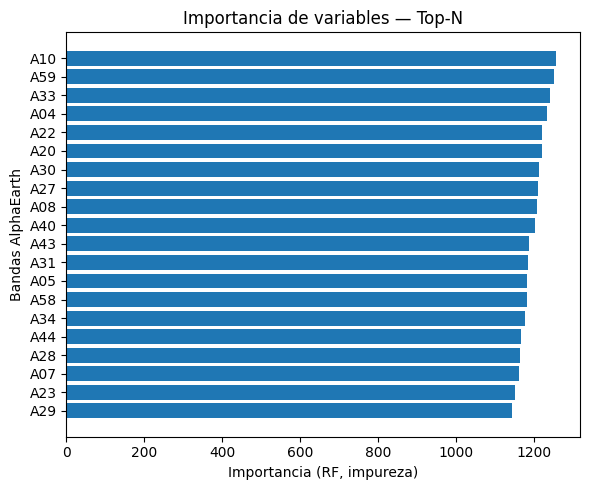

In [24]:
# === 17.2 (Opcional) Gráfica de barras (Top-N) ===
import matplotlib.pyplot as plt

names, vals = zip(*top_sorted) if top_sorted else ([], [])
plt.figure(figsize=(6, max(3, 0.25*len(names))))
plt.barh(names[::-1], vals[::-1])     # no especifices colores para mantener estilo simple
plt.xlabel("Importancia (RF, impureza)")
plt.ylabel("Bandas AlphaEarth")
plt.title("Importancia de variables — Top-N")
plt.tight_layout()
plt.show()
